# 00 — Stratified Scene Selection for v1.0-trainval Subset
## Multi-Attribute Scene Classification on nuScenes

**Purpose:** Select 150 scenes from v1.0-trainval (out of 850 available) via stratified random sampling to form the Stage 2 experimental subset.

### Why a stratified subset?

The full v1.0-trainval has 850 scenes (~34,000 keyframes). Running the full pipeline on all of it would require:
- ~330 GB image download
- ~20+ hours pipeline runtime
- Disk space well beyond practical academic constraints

A 150-scene stratified subset gives us:
- **15× scale-up from v1.0-mini** (10 scenes)
- **~6,000 keyframes** — adequate statistical power
- **~5-7 GB images** (only the selected scenes' CAM_FRONT)
- **~6-9 hours pipeline runtime** — manageable overnight run
- **Reproducible** by markers if they choose

### Stratification design

We stratify on `time_of_day × weather` to ensure each combination has adequate representation:

| Stratum | Quota | Available in trainval | Sampling rate |
|---|---|---|---|
| day_clear | 95 | 602 | 15.8% |
| day_rain | 25 | 149 | 16.8% |
| night_clear | 25 | 83 | 30.1% |
| night_rain | 5 | 16 | 31.2% |
| **Total** | **150** | **850** | **17.6%** |

### Design rationale

- **Deliberate oversampling of minority strata** (night, night_rain) for evaluation power
- **night_rain at 5** (not 10): only 16 scenes exist in trainval — taking 5 (31%) preserves out-of-sample reservoir; taking 10 (63%) would overfit to the population
- **Reproducible**: seed=42 fixed; markers can run the same selection

### Prerequisites

- ✅ `01a_metadata_eda.ipynb` was run (produces `scene_summary.csv`)


## 0. Setup

In [2]:
import os
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100

print('Imports OK')

Imports OK


## 0.1 Locate Project Root

In [3]:
def find_project_root():
    p = Path.cwd().resolve()
    for candidate in [p, *p.parents]:
        if (candidate / 'README.md').exists() and (candidate / 'notebooks').exists():
            return candidate
    raise FileNotFoundError(
        f'Could not find project root from {p}. '
        f'Looking for parent containing both README.md and notebooks/'
    )

PROJECT_ROOT = find_project_root()
os.chdir(PROJECT_ROOT)
print(f'Project root: {PROJECT_ROOT}')

Project root: C:\Users\leemi\Documents\GitHub\nuscenes-scene-classification-ml


## 1. Configuration

In [4]:
DATASET_VERSION = 'v1.0-trainval'
SUBSET_SEED = 42

# Output paths
META_DIR    = Path('data/processed') / DATASET_VERSION / 'metadata'
OUT_DIR     = Path('data/processed') / DATASET_VERSION
RESULTS_DIR = Path('results') / DATASET_VERSION / 'metrics'
FIG_DIR     = Path('results') / DATASET_VERSION / 'figures'

for p in [OUT_DIR, RESULTS_DIR, FIG_DIR]:
    p.mkdir(parents=True, exist_ok=True)

# Stratification quotas (Option B — final design)
TARGET_QUOTAS = {
    ('day',   'clear'): 95,
    ('day',   'rain'):  25,
    ('night', 'clear'): 25,
    ('night', 'rain'):   5,
}
TARGET_TOTAL = sum(TARGET_QUOTAS.values())

print(f'DATASET_VERSION = {DATASET_VERSION}')
print(f'SUBSET_SEED     = {SUBSET_SEED}')
print(f'TARGET_TOTAL    = {TARGET_TOTAL} scenes')
print()
print('Target quotas:')
for (tod, wx), q in TARGET_QUOTAS.items():
    print(f'  {tod:6s} / {wx:5s}: {q}')

DATASET_VERSION = v1.0-trainval
SUBSET_SEED     = 42
TARGET_TOTAL    = 150 scenes

Target quotas:
  day    / clear: 95
  day    / rain : 25
  night  / clear: 25
  night  / rain : 5


## 2. Load Scene Summary (from `01a_metadata_eda.ipynb`)

In [5]:
scene_summary_path = META_DIR / 'scene_summary.csv'
if not scene_summary_path.exists():
    raise FileNotFoundError(
        f'{scene_summary_path} does not exist.\n'
        f'Run 01a_metadata_eda.ipynb first to generate the scene summary.'
    )

df_scenes = pd.read_csv(scene_summary_path)
print(f'Loaded {len(df_scenes)} scenes from {scene_summary_path}')
print()
print('Columns:', df_scenes.columns.tolist())
print()
print('First few rows:')
print(df_scenes.head())

Loaded 850 scenes from data\processed\v1.0-trainval\metadata\scene_summary.csv

Columns: ['scene_token', 'scene_name', 'description', 'location', 'n_samples', 'log_token', 'time_of_day', 'weather']

First few rows:
                        scene_token  scene_name  \
0  73030fb67d3c46cfb5e590168088ae39  scene-0001   
1  c3e0e9f6ee8d4170a3d22a6179f1ca3a  scene-0002   
2  e7ef871f77f44331aefdebc24ec034b7  scene-0003   
3  25496f19ffd14bd088cb430bfc01a4d7  scene-0004   
4  6f5133fe62b240e797bac25aeff8b531  scene-0005   

                                         description            location  \
0      Construction, maneuver between several trucks  singapore-onenorth   
1  Intersection, peds, waiting vehicle, parked mo...  singapore-onenorth   
2             Parking lot, barrier, exit parking lot  singapore-onenorth   
3  Random scene, arrive at intersection, cross in...  singapore-onenorth   
4               Overtaken by taxi, construction site  singapore-onenorth   

   n_samples         

## 3. Verify Stratum Availability

In [6]:
print('=' * 70)
print('STRATUM AVAILABILITY CHECK')
print('=' * 70)
print()
print(f'{"Stratum":<20} {"Target":>8} {"Available":>12} {"Status":>20}')
print('-' * 70)

availability = []
all_feasible = True
for (tod, wx), target in TARGET_QUOTAS.items():
    available = len(df_scenes[(df_scenes['time_of_day'] == tod) &
                                (df_scenes['weather'] == wx)])
    status = '✓ feasible' if available >= target else f'⚠️ short by {target - available}'
    if available < target:
        all_feasible = False
    availability.append({
        'time_of_day': tod, 'weather': wx,
        'target': target, 'available': available,
        'feasible': available >= target,
    })
    print(f'{tod + "/" + wx:<20} {target:>8} {available:>12} {status:>20}')

print('-' * 70)
print(f'{"TOTAL":<20} {TARGET_TOTAL:>8} {sum(a["available"] for a in availability):>12}')
print()

if not all_feasible:
    raise ValueError('Some strata are short. Adjust TARGET_QUOTAS or design.')
print('✓ All strata feasible — proceed with sampling')

STRATUM AVAILABILITY CHECK

Stratum                Target    Available               Status
----------------------------------------------------------------------
day/clear                  95          602           ✓ feasible
day/rain                   25          149           ✓ feasible
night/clear                25           83           ✓ feasible
night/rain                  5           16           ✓ feasible
----------------------------------------------------------------------
TOTAL                     150          850

✓ All strata feasible — proceed with sampling


## 4. Stratified Random Sampling

In [7]:
rng = np.random.default_rng(SUBSET_SEED)
selected_rows = []

for (tod, wx), quota in TARGET_QUOTAS.items():
    stratum = df_scenes[(df_scenes['time_of_day'] == tod) &
                        (df_scenes['weather'] == wx)].copy()
    n_available = len(stratum)

    # Reproducible random sample without replacement
    chosen_indices = rng.choice(n_available, size=quota, replace=False)
    chosen = stratum.iloc[chosen_indices].copy()
    chosen['stratum'] = f'{tod}_{wx}'
    selected_rows.append(chosen)

    print(f'{tod:6s} / {wx:5s}: sampled {len(chosen)} of {n_available} scenes')

df_selected = pd.concat(selected_rows, ignore_index=True)
print(f'\n✓ Total selected: {len(df_selected)} scenes')

day    / clear: sampled 95 of 602 scenes
day    / rain : sampled 25 of 149 scenes
night  / clear: sampled 25 of 83 scenes
night  / rain : sampled 5 of 16 scenes

✓ Total selected: 150 scenes


## 5. Verify Selection

In [8]:
# Confirm no duplicates
n_unique_tokens = df_selected['scene_token'].nunique()
assert n_unique_tokens == len(df_selected), \
    f'Duplicate scene_tokens detected: {len(df_selected)} rows but {n_unique_tokens} unique'

# Confirm stratification matches target
selected_strata = df_selected.groupby(['time_of_day', 'weather']).size().to_dict()
print('Selected stratum counts:')
for (tod, wx), q in TARGET_QUOTAS.items():
    actual = selected_strata.get((tod, wx), 0)
    status = '✓' if actual == q else '✗'
    print(f'  {tod:6s} / {wx:5s}: target {q}, actual {actual} {status}')

print(f'\n✓ All {n_unique_tokens} scene_tokens are unique')

Selected stratum counts:
  day    / clear: target 95, actual 95 ✓
  day    / rain : target 25, actual 25 ✓
  night  / clear: target 25, actual 25 ✓
  night  / rain : target 5, actual 5 ✓

✓ All 150 scene_tokens are unique


## 6. Selected Scenes Summary

In [9]:
print('Selected scenes by location:')
print(df_selected['location'].value_counts())
print()

# Total keyframes covered
total_keyframes = df_selected['n_samples'].sum()
print(f'Total keyframes in selected subset: {total_keyframes}')
print(f'Mean keyframes per scene: {df_selected["n_samples"].mean():.1f}')
print(f'Min keyframes per scene:  {df_selected["n_samples"].min()}')
print(f'Max keyframes per scene:  {df_selected["n_samples"].max()}')

Selected scenes by location:
location
boston-seaport              79
singapore-onenorth          32
singapore-hollandvillage    23
singapore-queenstown        16
Name: count, dtype: int64

Total keyframes in selected subset: 6021
Mean keyframes per scene: 40.1
Min keyframes per scene:  39
Max keyframes per scene:  41


## 7. Visualize Selection vs Full v1.0-trainval

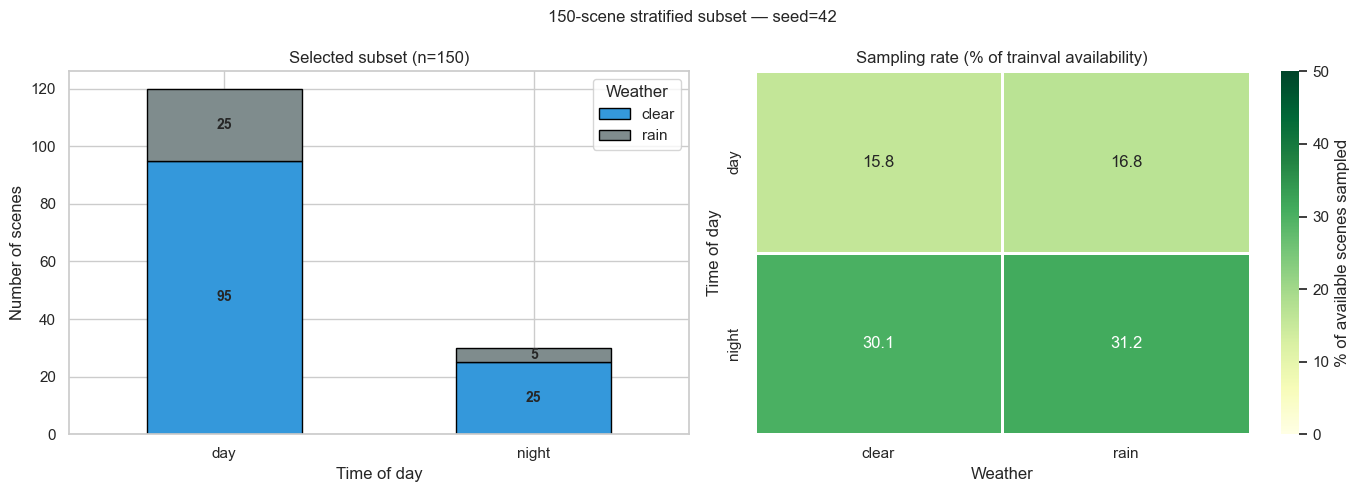

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel A — selected stratum distribution
selected_pivot = df_selected.groupby(['time_of_day', 'weather']).size().unstack('weather')
selected_pivot = selected_pivot.reindex(index=['day', 'night'], columns=['clear', 'rain'])
selected_pivot.plot(kind='bar', stacked=True, ax=axes[0],
                     color=['#3498db', '#7f8c8d'], edgecolor='black')
axes[0].set_title(f'Selected subset (n={len(df_selected)})')
axes[0].set_ylabel('Number of scenes')
axes[0].set_xlabel('Time of day')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Weather')
for container in axes[0].containers:
    axes[0].bar_label(container, label_type='center', fontsize=10, fontweight='bold')

# Panel B — sampling rate per stratum
av_pivot = df_scenes.groupby(['time_of_day', 'weather']).size().unstack('weather')
av_pivot = av_pivot.reindex(index=['day', 'night'], columns=['clear', 'rain'])
sampling_rate = (selected_pivot / av_pivot * 100).round(1)
sns.heatmap(sampling_rate, annot=True, fmt='.1f', cmap='YlGn',
            ax=axes[1], cbar_kws={'label': '% of available scenes sampled'},
            linewidths=1, vmin=0, vmax=50)
axes[1].set_title('Sampling rate (% of trainval availability)')
axes[1].set_xlabel('Weather')
axes[1].set_ylabel('Time of day')

plt.suptitle(f'150-scene stratified subset — seed={SUBSET_SEED}', fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR / 'selection_distribution.png', bbox_inches='tight')
plt.show()

## 8. Save Outputs

In [11]:
# Main output: selected_scenes.csv
selected_path = OUT_DIR / 'selected_scenes.csv'
df_selected.to_csv(selected_path, index=False)
print(f'Saved → {selected_path}  ({len(df_selected)} scenes)')

# Selection metadata JSON
selection_metadata = {
    'dataset_version':   DATASET_VERSION,
    'subset_seed':       SUBSET_SEED,
    'n_selected_scenes': int(len(df_selected)),
    'n_total_scenes':    int(len(df_scenes)),
    'sampling_fraction': round(len(df_selected) / len(df_scenes), 4),
    'target_quotas': {
        f'{tod}_{wx}': q for (tod, wx), q in TARGET_QUOTAS.items()
    },
    'actual_counts': {
        f'{tod}_{wx}': int(selected_strata.get((tod, wx), 0))
        for (tod, wx) in TARGET_QUOTAS.keys()
    },
    'available_in_trainval': {
        f'{a["time_of_day"]}_{a["weather"]}': int(a['available'])
        for a in availability
    },
    'sampling_rate_per_stratum': {
        f'{tod}_{wx}': round(selected_strata.get((tod, wx), 0) /
                              [a['available'] for a in availability if a['time_of_day'] == tod and a['weather'] == wx][0], 4)
        for (tod, wx) in TARGET_QUOTAS.keys()
    },
    'total_keyframes_estimated': int(total_keyframes),
    'location_distribution': df_selected['location'].value_counts().to_dict(),
}

with open(OUT_DIR / 'selection_metadata.json', 'w') as f:
    json.dump(selection_metadata, f, indent=2)
print(f'Saved → {OUT_DIR / "selection_metadata.json"}')
print()
print(json.dumps(selection_metadata, indent=2))

Saved → data\processed\v1.0-trainval\selected_scenes.csv  (150 scenes)
Saved → data\processed\v1.0-trainval\selection_metadata.json

{
  "dataset_version": "v1.0-trainval",
  "subset_seed": 42,
  "n_selected_scenes": 150,
  "n_total_scenes": 850,
  "sampling_fraction": 0.1765,
  "target_quotas": {
    "day_clear": 95,
    "day_rain": 25,
    "night_clear": 25,
    "night_rain": 5
  },
  "actual_counts": {
    "day_clear": 95,
    "day_rain": 25,
    "night_clear": 25,
    "night_rain": 5
  },
  "available_in_trainval": {
    "day_clear": 602,
    "day_rain": 149,
    "night_clear": 83,
    "night_rain": 16
  },
  "sampling_rate_per_stratum": {
    "day_clear": 0.1578,
    "day_rain": 0.1678,
    "night_clear": 0.3012,
    "night_rain": 0.3125
  },
  "total_keyframes_estimated": 6021,
  "location_distribution": {
    "boston-seaport": 79,
    "singapore-onenorth": 32,
    "singapore-hollandvillage": 23,
    "singapore-queenstown": 16
  }
}


## 9. Summary

In [12]:
print('=' * 70)
print('SCENE SELECTION COMPLETE')
print('=' * 70)
print()
print(f'  Selected:   {len(df_selected)} scenes (out of {len(df_scenes)} in v1.0-trainval)')
print(f'  Seed:       {SUBSET_SEED}')
print(f'  Keyframes:  ~{total_keyframes} keyframes total')
print()
print('Stratum breakdown:')
for (tod, wx) in TARGET_QUOTAS.keys():
    actual = selected_strata.get((tod, wx), 0)
    print(f'  {tod:6s} / {wx:5s}: {actual} scenes')
print()
print('=' * 70)
print('NEXT STEPS')
print('=' * 70)
print()
print('1. Run 01b_blob_mapping.ipynb')
print('   → Analyzes which blob archives contain your selected scenes\' images')
print('   → Outputs blob_priority.csv (which blobs to download in priority order)')
print()
print('2. Download blobs in priority order from nuscenes.org')
print('   → Start with highest-priority blob')
print('   → Each blob: download → extract → check missing files → next blob')
print()
print('3. Continue with rest of Stage 2 pipeline once images are extracted')

SCENE SELECTION COMPLETE

  Selected:   150 scenes (out of 850 in v1.0-trainval)
  Seed:       42
  Keyframes:  ~6021 keyframes total

Stratum breakdown:
  day    / clear: 95 scenes
  day    / rain : 25 scenes
  night  / clear: 25 scenes
  night  / rain : 5 scenes

NEXT STEPS

1. Run 01b_blob_mapping.ipynb
   → Analyzes which blob archives contain your selected scenes' images
   → Outputs blob_priority.csv (which blobs to download in priority order)

2. Download blobs in priority order from nuscenes.org
   → Start with highest-priority blob
   → Each blob: download → extract → check missing files → next blob

3. Continue with rest of Stage 2 pipeline once images are extracted


---
## Reproducibility note

This selection is **fully reproducible**. Any marker (or future you) can reproduce the exact 150 scenes by:

1. Loading the same v1.0-trainval metadata
2. Running this notebook with `SUBSET_SEED = 42`
3. The same scenes will be selected (deterministic numpy RNG)

The selection is also documented as a list of `scene_token` values in `selected_scenes.csv`, providing a permanent record independent of the selection logic.
